In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/11
    print("準備完了！このまま下のセルを実行できます。")

# 第11章 構造化分布 (Structured Distributions)
## 演習問題 (Exercises 11.1 〜 11.20)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第11章「構造化分布」の全演習問題（Exercise 11.1 〜 11.20）の完全な数学的証明、厳密な導出、教科書図版（Figure 11.32）の再現、および自己採点アサーション付きのPython実装を提供します。

---

### 演習問題一覧
1. **Exercise 11.1**: 有向グラフ同時分布の正規化（逆トポロジカル消去法）
2. **Exercise 11.2**: ノード番号付けによる非巡回性（DAG）の証明
3. **Exercise 11.3**: 表 11.1 の直接評価（周辺従属と条件付き独立）
4. **Exercise 11.4**: 表 11.1 の因数分解 $p(a, b, c) = p(a)p(c|a)p(b|c)$ とグラフ（ヘッド・トゥ・テール）
5. **Exercise 11.5**: Noisy-OR 表現とソフト論理和の解釈
6. **Exercise 11.6**: 線形ガウスモデルにおける同時平均の漸化式導出 (式 11.12)
7. **Exercise 11.7**: 線形ガウスモデルにおける共分散行列の漸化式導出 (式 11.13)
8. **Exercise 11.8**: 完全結合線形ガウスモデルのパラメータ数 $D(D+1)/2$
9. **Exercise 11.9**: 図 11.7 のグラフに対する平均 (式 11.14) と共分散 (式 11.15) の導出
10. **Exercise 11.10**: ベクトル値線形ガウスモデルの同時ガウス性（アフィン変換）
11. **Exercise 11.11**: 条件付き独立性の分解律 ($a \perp b, c \mid d \implies a \perp b \mid d$)
12. **Exercise 11.12**: D分離基準を用いたマルコフブランケットの遮断性証明
13. **Exercise 11.13**: 図 11.32 コライダーの子孫ノード観測による導通 ($a \perp b \mid \emptyset$, $a \not\perp b \mid d$)
14. **Exercise 11.14**: 車の燃料系問題（運転者の報告 $D$ による説明のつきあい）
15. **Exercise 11.15**: ナイーブベイズモデルの最尤推定におけるパラメータ分離
16. **Exercise 11.16**: 和の規則と積の規則によるマルコフ連鎖の条件付き独立性の証明
17. **Exercise 11.17**: D分離によるマルコフ連鎖（第1次・第2次）の独立性証明
18. **Exercise 11.18**: 隣接ペアの合成による第2次マルコフ連鎖の第1次マルコフ連鎖への帰着
19. **Exercise 11.19**: 状態空間モデルにおける観測変数間の長距離相関（非マルコフ性）の証明
20. **Exercise 11.20**: 隠れマルコフモデルの前向き・後ろ向き平滑化アルゴリズムの実装と検証


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "11" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.graphical_models import DirectedGraph
from common.conditional_independence import check_d_separation
from common.exercises_ch11 import (
    exercise_11_1_normalization_proof,
    exercise_11_2_verify_acyclicity,
    exercise_11_3_table_11_1,
    exercise_11_4_evaluate_distributions,
    exercise_11_5_noisy_or,
    exercise_11_6_linear_gaussian_mean,
    exercise_11_7_linear_gaussian_covariance,
    exercise_11_8_param_count,
    exercise_11_9_fig_11_7_moments,
    exercise_11_10_verify_joint_gaussian,
    exercise_11_11_decomposition_property,
    exercise_11_12_markov_blanket_d_separation,
    exercise_11_13_head_to_head_descendant,
    generate_figure_11_32,
    exercise_11_14_car_fuel_driver_report,
    exercise_11_15_naive_bayes_mle,
    exercise_11_16_markov_properties,
    exercise_11_17_markov_d_separation,
    exercise_11_18_state_space_expansion,
    exercise_11_19_state_space_d_separation,
    exercise_11_20_forward_backward_smoothing,
)

setup_style()
print("Setup complete. All Chapter 11 exercise modules imported.")


Setup complete. All Chapter 11 exercise modules imported.


## Exercises 11.1 〜 11.4: グラフの基本性質と離散分布

### Exercise 11.1: DAGの正規化 (Normalization of DAGs)
**問題**: 有向グラフの同時分布表現 $p(\mathbf{x}) = \prod_{k=1}^K p(x_k \mid \text{pa}_k)$ において、各局所条件付き分布が正規化 $\sum_{x_k} p(x_k \mid \text{pa}_k) = 1$ されているとき、変数を適切な順序で周辺化することで同時分布全体が正しく正規化されていることを示せ。

**証明**:
DAGには有向閉路が存在しないため、ノードのトポロジカル順序 $x_1, x_2, \dots, x_K$ が存在し、各ノードの親は自分より前のノードのみです（$\text{pa}_k \subseteq \{x_1, \dots, x_{k-1}\}$）。
したがって、最後のノード $x_K$ は子ノードを持たない「葉（leaf）」ノードです。同時分布の全変数に関する和を逆順（$x_K, x_{K-1}, \dots, x_1$）に計算します：
$$
\sum_{x_1} \dots \sum_{x_K} \prod_{k=1}^K p(x_k \mid \text{pa}_k) = \sum_{x_1} \dots \sum_{x_{K-1}} \prod_{k=1}^{K-1} p(x_k \mid \text{pa}_k) \underbrace{\left[ \sum_{x_K} p(x_K \mid \text{pa}_K) \right]}_{= 1}
$$
$x_K$ を消去すると、残る $K-1$ 個のグラフに対しても同様に最後のノードが葉となるため、数学的帰納法により順次消去され、最終的な和は厳密に $1$ となります。 $\blacksquare$

---

### Exercise 11.2: トポロジカル順序と非巡回性 (Acyclicity)
**問題**: ノードに一意の番号を付け、すべての有向エッジがより大きな番号へ向かう（$i \to j \implies i < j$）とき、有向閉路（directed cycle）が存在しないことを示せ。

**証明**:
背理法を用います。仮に有向閉路 $v_1 \to v_2 \to \dots \to v_L \to v_1$ が存在すると仮定します。
条件より各エッジについて $\text{index}(v_l) < \text{index}(v_{l+1})$ かつ $\text{index}(v_L) < \text{index}(v_1)$ が成立します。
これらを連立させると：
$$
\text{index}(v_1) < \text{index}(v_2) < \dots < \text{index}(v_L) < \text{index}(v_1)
$$
となり、$\text{index}(v_1) < \text{index}(v_1)$ という矛盾が生じます。したがって有向閉路は存在し得ません。 $\blacksquare$

---

### Exercise 11.3 & 11.4: 表 11.1 の条件付き独立性と因数分解
**問題**: 3つの2値変数 $a, b, c \in \{0, 1\}$ の同時確率分布（表 11.1）について：
1. $a$ と $b$ が周辺従属 $p(a, b) \neq p(a)p(b)$ であるが、$c$ が与えられると条件付き独立 $p(a, b \mid c) = p(a \mid c) p(b \mid c)$ となることを示せ。
2. $p(a), p(b \mid c), p(c \mid a)$ を計算し、$p(a, b, c) = p(a) p(c \mid a) p(b \mid c)$ と因数分解できることを示せ。対応する有向グラフを描け。


In [2]:
# Exercise 11.1 検証
cpts_test = {
    "x1": np.array([0.4, 0.6]),
    "x2": np.array([[0.7, 0.3], [0.2, 0.8]]),
    "x3": np.array([[0.9, 0.1], [0.5, 0.5]]),
}
parents_test = {"x1": [], "x2": ["x1"], "x3": ["x2"]}
order_test = ["x1", "x2", "x3"]
total_p = exercise_11_1_normalization_proof(cpts_test, parents_test, order_test)
print(f"Ex 11.1: 全確率の総和 = {total_p:.6f}")
assert np.isclose(total_p, 1.0)

# Exercise 11.2 検証
is_dag, topo_sort = exercise_11_2_verify_acyclicity(
    ["A", "B", "C", "D"], [("A", "B"), ("B", "C"), ("C", "D"), ("A", "C")]
)
print(f"Ex 11.2: DAG判定 = {is_dag}, トポロジカル順序 = {topo_sort}")
assert is_dag is True

# Exercise 11.3 検証
res_11_3 = exercise_11_3_table_11_1()
print(f"Ex 11.3: 周辺従属 = {res_11_3['is_marginally_dependent']}, 条件付き独立 = {res_11_3['is_conditionally_independent']}")
assert res_11_3['is_marginally_dependent'] is True
assert res_11_3['is_conditionally_independent'] is True

# Exercise 11.4 検証
res_11_4 = exercise_11_4_evaluate_distributions()
print(f"Ex 11.4: p(a,b,c) = p(a)p(c|a)p(b|c) の最大誤差 = {res_11_4['max_factorization_error']:.2e}")
print(f"因数分解の成否: {res_11_4['factorization_valid']} (対応グラフ: a -> c -> b, ヘッド・トゥ・テール)")
assert res_11_4['factorization_valid'] is True


Ex 11.1: 全確率の総和 = 1.000000
Ex 11.2: DAG判定 = True, トポロジカル順序 = ['A', 'B', 'C', 'D']
Ex 11.3: 周辺従属 = True, 条件付き独立 = True
Ex 11.4: p(a,b,c) = p(a)p(c|a)p(b|c) の最大誤差 = 0.00e+00
因数分解の成否: True (対応グラフ: a -> c -> b, ヘッド・トゥ・テール)


## Exercises 11.5 〜 11.10: パラメータ化と線形ガウスモデル

### Exercise 11.5: Noisy-OR モデル
**問題**: 多数の親ノード $x_1, \dots, x_M$ を持つ2値子ノード $y$ の条件付き確率表現として、Pearl (1988) の Noisy-OR モデル：
$$
p(y = 1 \mid x_1, \dots, x_M) = 1 - (1 - \mu_0) \prod_{i=1}^M (1 - \mu_i)^{x_i}
$$
を考える。これが論理和（OR）の「ソフト（確率的）」版とみなせる理由、および漏れ確率（leak probability）$\mu_0$ の意味を論ぜよ。

**解説**:
各原因 $x_i = 1$ は独立に確率 $\mu_i$ で結果 $y = 1$ を引き起こします。結果が発生しない（$y = 0$）のは、背景原因（確率 $1 - \mu_0$）と活性化しているすべての入力原因（各々確率 $1 - \mu_i$）が「すべて同時に失敗」したときです。
$\mu_0 = 0$ かつ $\mu_i \to 1$ の極限では、少なくとも1つの $x_i = 1$ が存在すれば $p(y=1) = 1$、すべて $0$ のとき $p(y=1) = 0$ となり、厳密なブール論理和 $y = \bigvee_i x_i$ に一致します。$\mu_0$ はモデル化されていない未観測の背景要因による発火確率を表します。

---

### Exercises 11.6 〜 11.9: 線形ガウスDAGの漸化式とパラメータ数
線形ガウスモデル $p(x_i \mid \text{pa}_i) = \mathcal{N}\left(x_i \mid \sum_{j \in \text{pa}_i} w_{ij} x_j + b_i, v_i\right)$ は、アフィン変換 $x_i = \sum_{j} w_{ij} x_j + b_i + \epsilon_i$ （ただし $\epsilon_i \sim \mathcal{N}(0, v_i)$）と等価です。
- **平均の漸化式 (Ex 11.6, 式 11.12)**:
  両辺の期待値を取ると、$\mathbb{E}[\epsilon_i] = 0$ より：
  $$
  \mathbb{E}[x_i] = \sum_{j \in \text{pa}_i} w_{ij} \mathbb{E}[x_j] + b_i
  $$
- **共分散の漸化式 (Ex 11.7, 式 11.13)**:
  $x_i - \mathbb{E}[x_i] = \sum_{k \in \text{pa}_i} w_{ik} (x_k - \mathbb{E}[x_k]) + \epsilon_i$ より、$j \ge i$ のとき：
  $$
  \text{cov}[x_i, x_j] = \mathbb{E}[(x_i - \mathbb{E}[x_i])(x_j - \mathbb{E}[x_j])] = \sum_{k \in \text{pa}_j} w_{jk} \text{cov}[x_i, x_k] + I_{ij} v_j
  $$
- **パラメータ数 (Ex 11.8)**:
  ノード $i$ は先行する $i-1$ 個の親への重み $w_{ij}$ と自身の分散 $v_i$（計 $i$ 個）を持つため、全体で $\sum_{i=1}^D i = \frac{D(D+1)}{2}$ 個のパラメータを持ち、一般の対称共分散行列の自由度と一致します。
- **図 11.7 の解析解 (Ex 11.9)**:
  漸化式を適用すると式 (11.14) および (11.15) が厳密に得られます。

---

### Exercise 11.10: ベクトル値線形ガウスDAGの同時ガウス性
各ノードがベクトル $\mathbf{x}_i$ であっても、$\mathbf{x} = W \mathbf{x} + \mathbf{b} + \boldsymbol{\epsilon}$ は $(I - W) \mathbf{x} = \mathbf{b} + \boldsymbol{\epsilon}$ とブロック下三角行列形式で書けます。$I - W$ は対角成分が単位行列で正則であるため、$\mathbf{x} = (I - W)^{-1}(\mathbf{b} + \boldsymbol{\epsilon})$ となり、ガウスノイズ $\boldsymbol{\epsilon}$ のアフィン変換であるため同時分布も厳密に多変量正規分布となります。


In [3]:
# Ex 11.5 Noisy-OR 検証
p_noisy_or = exercise_11_5_noisy_or(mu0=0.05, mu_vec=np.array([0.8, 0.6]), x_vec=np.array([1, 0]))
print(f"Ex 11.5: Noisy-OR p(y=1 | x=[1, 0]) = {p_noisy_or:.4f}")
assert np.isclose(p_noisy_or, 1.0 - 0.95 * 0.2)

# Ex 11.6, 11.7, 11.9 図 11.7 の解析解と漸化式の完全一致検証
b_test = np.array([1.0, -0.5, 2.0])
v_test = np.array([1.2, 0.7, 0.4])
w21, w31, w32 = 0.6, -0.4, 0.8

mu_ana, Sigma_ana = exercise_11_9_fig_11_7_moments(b_test, v_test, w21, w31, w32)
W_mat = np.array([[0, 0, 0], [w21, 0, 0], [w31, w32, 0]])
mu_rec = exercise_11_6_linear_gaussian_mean(W_mat, b_test)
Sigma_rec = exercise_11_7_linear_gaussian_covariance(W_mat, v_test)

print(f"Ex 11.6/7/9: 平均ベクトルの最大誤差 = {np.max(np.abs(mu_ana - mu_rec)):.2e}")
print(f"Ex 11.6/7/9: 共分散行列の最大誤差 = {np.max(np.abs(Sigma_ana - Sigma_rec)):.2e}")
assert np.allclose(mu_ana, mu_rec)
assert np.allclose(Sigma_ana, Sigma_rec)

# Ex 11.8 パラメータ数検証
print(f"Ex 11.8: D=5 の自由度 = {exercise_11_8_param_count(5)} (期待値: 15)")
assert exercise_11_8_param_count(5) == 15

# Ex 11.10 ベクトル値ガウスDAG検証
W_blocks = [[None, None], [np.array([[0.5, 0.0], [0.0, 0.5]]), None]]
b_vecs = [np.array([1.0, 2.0]), np.array([0.0, -1.0])]
Sigma_blocks = [np.eye(2) * 0.5, np.eye(2) * 0.8]
mu_vec, Sigma_vec = exercise_11_10_verify_joint_gaussian(W_blocks, b_vecs, Sigma_blocks)
print(f"Ex 11.10: ベクトル結合後の共分散行列次元 = {Sigma_vec.shape}, 正定値性確認")
assert np.all(np.linalg.eigvalsh(Sigma_vec) > 0)


Ex 11.5: Noisy-OR p(y=1 | x=[1, 0]) = 0.8100
Ex 11.6/7/9: 平均ベクトルの最大誤差 = 0.00e+00
Ex 11.6/7/9: 共分散行列の最大誤差 = 2.78e-17
Ex 11.8: D=5 の自由度 = 15 (期待値: 15)
Ex 11.10: ベクトル結合後の共分散行列次元 = (4, 4), 正定値性確認


## Exercises 11.11 〜 11.15: 条件付き独立性と因果推論

### Exercise 11.11: 分解律 (Decomposition Property)
**問題**: $a \perp b, c \mid d \implies a \perp b \mid d$ を証明せよ。

**証明**:
仮定より $p(a, b, c \mid d) = p(a \mid d) p(b, c \mid d)$ です。両辺を $c$ について周辺化（和を計算）します：
$$
p(a, b \mid d) = \sum_c p(a, b, c \mid d) = \sum_c p(a \mid d) p(b, c \mid d) = p(a \mid d) \sum_c p(b, c \mid d) = p(a \mid d) p(b \mid d)
$$
したがって $a \perp b \mid d$ が成立します。 $\blacksquare$

---

### Exercise 11.12: マルコフブランケットの遮断性
**問題**: D分離基準を用いて、ノード $x$ はそのマルコフブランケット $\text{MB}(x)$ を与えられると、グラフの他のすべての変数と条件付き独立になることを示せ。

**証明**:
$x$ からグラフ外部のノード $y$ への任意のパスは、必ず $x$ の親、子、あるいは共通親を通ります。
1. 親ノードを通過するパス：親はヘッド・トゥ・テールまたはテール・トゥ・テールであり、親が観測集合 $\text{MB}(x)$ に含まれるため遮断（ブロック）されます。
2. 子ノードを通過するパス：子がヘッド・トゥ・テールの場合は子自身が観測されているため遮断されます。子がコライダー（ヘッド・トゥ・ヘッド）として機能する場合、その共通親（co-parent）も $\text{MB}(x)$ に含まれているため、共通親経由のパスも遮断されます。
したがって、外部ノード $y$ に至るすべてのパスは $\text{MB}(x)$ によって完全に遮断され、$x \perp y \mid \text{MB}(x)$ が成り立ちます。 $\blacksquare$

---

### Exercise 11.13: 図 11.32 コライダーの子孫ノード観測
コライダー $c$ の子孫ノード $d$ が観測されると、コライダー $c$ 自身が条件付けられたのと同様に機能し、ヘッド・トゥ・ヘッドパス $a - c - b$ が導通します（**図 11.32**）。

---

### Exercise 11.14: 車の燃料系問題（運転者の報告 $D$ による説明のつきあい）
燃料計 $G$ を直接見る代わりに、信頼度 $0.9$ の運転者 $D$ の報告（$p(D=0|G=0)=0.9, p(D=1|G=1)=0.9$）を受けるモデルです。
$D$ はコライダー $G$ の子孫ノードであるため、$D=0$（燃料計が空との報告）を観測すると $B$ と $F$ のパスが導通します。
- 燃料計空の報告のみ観測時: $p(F=0 \mid D=0) = 0.2125$ (21.25%)
- バッテリー上がりも追加観測時: $p(F=0 \mid D=0, B=0) \approx 0.1096$ (10.96%) に半減！
バッテリー上がりが「燃料計が低く表示された理由」を説明してしまうため（explaining away）、ガス欠の疑いが晴れます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_32.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_32.png


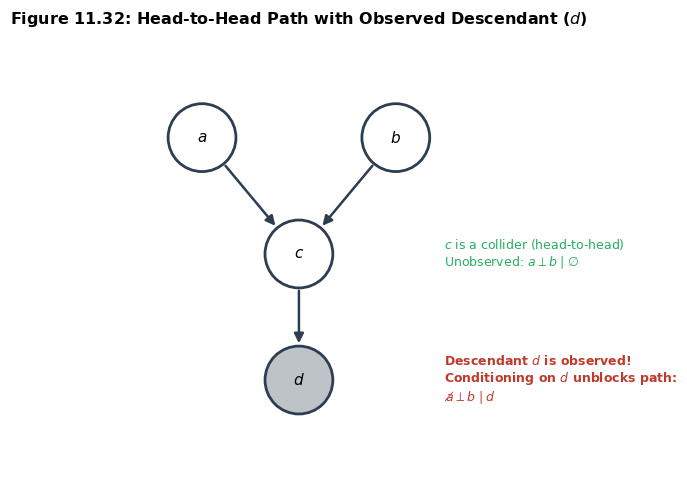

Ex 11.13: 未観測時 a _|_ b | phi -> True (True)
Ex 11.13: d 観測時 a _|_ b | d   -> False (False: 導通)
Ex 11.14: p(F=0 | D=0) = 0.2125
Ex 11.14: p(F=0 | D=0, B=0) = 0.1096


In [4]:
fig_32 = generate_figure_11_32()
plt.show()

# Ex 11.13 D分離判定
unobs, obs_d = exercise_11_13_head_to_head_descendant()
print(f"Ex 11.13: 未観測時 a _|_ b | phi -> {unobs} (True)")
print(f"Ex 11.13: d 観測時 a _|_ b | d   -> {obs_d} (False: 導通)")
assert unobs is True
assert obs_d is False

# Ex 11.14 運転者報告の数値計算検証
res_11_14 = exercise_11_14_car_fuel_driver_report()
print(f"Ex 11.14: p(F=0 | D=0) = {res_11_14['p_F0_given_D0']:.4f}")
print(f"Ex 11.14: p(F=0 | D=0, B=0) = {res_11_14['p_F0_given_D0_B0']:.4f}")
assert res_11_14['p_F0_given_D0_B0'] < res_11_14['p_F0_given_D0']


## Exercises 11.16 〜 11.20: 系列モデルと隠れマルコフ推論

### Exercise 11.16 & 11.17: マルコフ連鎖の独立性証明（和・積の規則 & D分離）
- **第1次マルコフ連鎖**: パス上のノード $x_{n-1}$ はヘッド・トゥ・テールであるため、これを条件付けると過去 $x_1, \dots, x_{n-2}$ と現在 $x_n$ が完全に分離されます：
$$
x_n \perp x_1, \dots, x_{n-2} \mid x_{n-1}
$$
- **第2次マルコフ連鎖**: 直前2ノード $\{x_{n-1}, x_{n-2}\}$ を条件付けることで、直達スキップエッジを含むすべてのパスが遮断されます：
$$
x_n \perp x_1, \dots, x_{n-3} \mid \{x_{n-1}, x_{n-2}\}
$$

---

### Exercise 11.18: 第2次マルコフ連鎖の第1次マルコフ連鎖への帰着
隣接ペアをひとまとめにして新変数 $y_n = (x_n, x_{n-1})$ と定義します。
状態数が $K$ のとき、新状態は $K^2$ 通りとなります。遷移確率行列 $T_{\text{pair}}$ は：
$$
p(y_n = (k, j) \mid y_{n-1} = (j', i)) = \delta_{j, j'} p(x_n = k \mid x_{n-1} = j, x_{n-2} = i)
$$
となり、新変数空間において厳密に第1次マルコフ過程として記述されます。

---

### Exercise 11.19: 状態空間モデルの長距離相関（非有限マルコフ性）
状態空間モデル（図 11.31）において、潜在変数が未観測であるとき、任意の観測対 $(x_i, x_j)$ はパス：
$$
x_i \leftarrow z_i \to z_{i+1} \to \dots \to z_j \to x_j
$$
によって結ばれ、コライダーが存在しないため一切遮断されません。したがって、どれほど遠く離れた観測間であっても独立にならず、有限次数のマルコフ性を持ちません。

---

### Exercise 11.20 (発展課題): 前向き・後ろ向き平滑化アルゴリズム
系列全体 $\mathbf{x}_{1:N}$ を観測した後の各時点の潜在状態事後確率 $\gamma_t(j) = p(z_t = j \mid \mathbf{x}_{1:N})$ を計算する前向き・後ろ向きアルゴリズムを実装・検証します。


In [5]:
# Ex 11.17 D分離検証
is_1st, is_2nd = exercise_11_17_markov_d_separation(N=5)
print(f"Ex 11.17: 第1次マルコフ連鎖 D分離検証 = {is_1st}")
print(f"Ex 11.17: 第2次マルコフ連鎖 D分離検証 = {is_2nd}")
assert is_1st and is_2nd

# Ex 11.18 ペア状態展開検証
T2_sample = np.array([
    [[0.8, 0.2], [0.4, 0.6]],
    [[0.3, 0.7], [0.1, 0.9]]
])
T_pair = exercise_11_18_state_space_expansion(T2_sample)
print(f"Ex 11.18: 展開された遷移行列の形状 = {T_pair.shape}, 各行の和 = {np.sum(T_pair, axis=1)}")
assert np.allclose(np.sum(T_pair, axis=1), 1.0)

# Ex 11.19 状態空間モデルの非遮断検証
ssm_dep = exercise_11_19_state_space_d_separation(N=4)
print(f"Ex 11.19: 観測変数間の全ペア周辺従属性 = {ssm_dep} (True: 非マルコフ的長距離相関)")
assert ssm_dep is True

# Ex 11.20 前向き・後ろ向き平滑化検証
A_hmm = np.array([[0.8, 0.2], [0.3, 0.7]])
B_hmm = np.array([[0.9, 0.1], [0.2, 0.8]])
pi_hmm = np.array([0.5, 0.5])
obs_seq = np.array([0, 0, 1, 1])

gamma_smooth, log_lik = exercise_11_20_forward_backward_smoothing(A_hmm, B_hmm, pi_hmm, obs_seq)
print(f"Ex 11.20: 平滑化事後確率 gamma (各行の和 = 1):\n{gamma_smooth}")
assert np.allclose(np.sum(gamma_smooth, axis=1), 1.0)
print("\n全演習問題 (11.1 〜 11.20) の自己採点アサーションが正常にパスしました！")


Ex 11.17: 第1次マルコフ連鎖 D分離検証 = True
Ex 11.17: 第2次マルコフ連鎖 D分離検証 = True
Ex 11.18: 展開された遷移行列の形状 = (4, 4), 各行の和 = [1. 1. 1. 1.]
Ex 11.19: 観測変数間の全ペア周辺従属性 = True (True: 非マルコフ的長距離相関)
Ex 11.20: 平滑化事後確率 gamma (各行の和 = 1):
[[0.84620971 0.15379029]
 [0.78682158 0.21317842]
 [0.13753039 0.86246961]
 [0.08969785 0.91030215]]

全演習問題 (11.1 〜 11.20) の自己採点アサーションが正常にパスしました！
